In [20]:
# Libraries
import os
import math

import torch
import gpytorch

torch.set_default_dtype(torch.float64)

import numpy as np

from scipy.stats import norm
from scipy.stats import multivariate_normal

# Project libraries
from core.gp import PrefGP_Gibbs, PrefGP_LA, Kernel
from utils.utility import UtilityOracle

In [21]:
# Matplotlib related
import matplotlib

# matplotlib.use("Agg") # Headless mode; no GUI
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {"text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"]}
)
plt.rc("text.latex", preamble=r"\usepackage{bm} ")
plt.rcParams["figure.constrained_layout.use"] = False

plt.rcParams["font.size"] = 30
plt.rcParams["axes.titlesize"] = 30
plt.rcParams["lines.linewidth"] = 3.0
plt.rcParams["image.cmap"] = "plasma"
plt.rcParams["axes.labelpad"] = 0.2
plt.rcParams["axes.axisbelow"] = True

plt.rcParams["legend.fontsize"] = 30
plt.rcParams["legend.borderpad"] = 0.2  # border whitespace
plt.rcParams[
    "legend.labelspacing"
] = 0.2  # the vertical space between the legend entries
plt.rcParams["legend.handlelength"] = 1.0  # the length of the legend lines
plt.rcParams["legend.handleheight"] = 0.3  # the height of the legend handle
plt.rcParams[
    "legend.handletextpad"
] = 0.3  # the space between the legend line and legend text
plt.rcParams[
    "legend.borderaxespad"
] = 0.1  # the border between the axes and legend edge
plt.rcParams["legend.columnspacing"] = 1.0  # column separation
plt.rcParams["image.cmap"] = "tab20c"

# Save all figures relative to the notebook working directory.
os.makedirs("./figures", exist_ok=True)


In [22]:
## Hyperparameters

# General
SEED = 0

# Kernel-related
LENGTH_SCALE = 0.05
CHOL_JITTER = 1e-8

# Training space
CANDIDATE_SIZE = 201 

# MCMC related
MC_SAMPLE_SIZE = 10000
MC_BURN_IN = 2000
MC_THINNING = 10

In [23]:
# Create a kernel
torch.manual_seed(SEED)

with torch.inference_mode():
    kernel = Kernel(kernel_name="RBFKernel", lengthscale=LENGTH_SCALE, use_scale=False)

    # Set the search space
    X = torch.linspace(0, 1, CANDIDATE_SIZE)

    prior_mean = torch.zeros(CANDIDATE_SIZE)
    prior_cov = kernel(X)
    prior_cov = 0.5 * (prior_cov + prior_cov.T) # Symmtrization

    prior_chol = torch.linalg.cholesky(prior_cov + CHOL_JITTER * torch.eye(CANDIDATE_SIZE))

    # Generate the true utility function
    true_f = prior_mean + (prior_chol @ torch.randn(CANDIDATE_SIZE).unsqueeze(1)).squeeze()
    X_max_idx = torch.argmax(true_f[100:]) + 100

print(X_max_idx)


tensor(100)


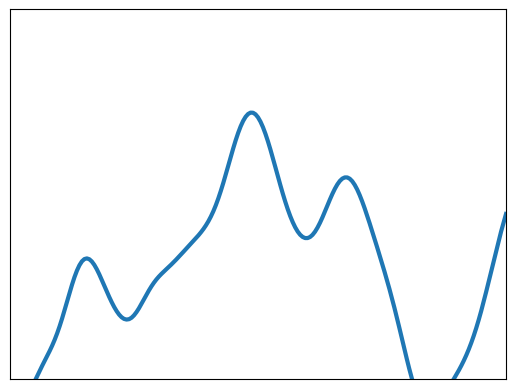

In [24]:
# Plotting the utility
plt.plot(X, true_f)
plt.xticks([], [])
plt.yticks([], [])
plt.xlim(0, 1)
plt.ylim(-2, 3.3)
plt.savefig("./figures/latent_func.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [25]:
# Problem space
n_train = 50
input_dim = 1

noise_std = 1e-2

with torch.inference_mode():
    # Original np.random.choice(...): sampling with replacement
    train_indices = torch.randint(
        0,
        CANDIDATE_SIZE,
        (2 * n_train,),
        device=X.device,
    )

    X_train = X[train_indices].reshape(
        n_train,
        2,
        input_dim,
    )

    y_train = true_f[train_indices].reshape(
        n_train,
        2,
    )

    # winner first
    sort_indices = torch.argsort(
        y_train,
        dim=1,
        descending=True,
    )

    # Sort y
    y_train = torch.gather(
        y_train,
        dim=1,
        index=sort_indices,
    )

    # Sort X
    X_train = torch.gather(
        X_train,
        dim=1,
        index=sort_indices.unsqueeze(-1).expand(-1, -1, input_dim),
    )

    # Sort candidate indices
    train_indices = train_indices.reshape(n_train, 2)

    train_indices = torch.gather(
        train_indices,
        dim=1,
        index=sort_indices,
    )

kernel = Kernel(kernel_name="RBFKernel", lengthscale=LENGTH_SCALE, use_scale=False)



In [26]:
## Sample posterior with MCMC

# Create the Gibbs sampling object
pgp_gibbs = PrefGP_Gibbs(
    kernel=kernel,
    kernel_length_scale=LENGTH_SCALE,
    noise_std=noise_std,
    input_dim=1,
    sample_size=MC_SAMPLE_SIZE,
    burn_in=MC_BURN_IN
)

# Set duel observation
pgp_gibbs.update_observations(X_train=X_train, Y_train=y_train)

# Run posterior inference on f(X_train)
posterior_mean, posterior_cov = pgp_gibbs.inference()

print("X:", X.shape)
print("X_unique:", pgp_gibbs.X_unique.shape)
print("X_train:", pgp_gibbs.X_train.shape)

# print(posterior_mean)
# print(posterior_mean.shape)
# print(posterior_cov)
# print(posterior_cov.shape)

# prediction on all utility points
pred_mean, pred_cov = pgp_gibbs.conditional_predict(X.unsqueeze(1), is_full_cov=False)

print(pred_mean.shape)
print(pred_mean[0, :10])
# print(pred_cov.shape)
# print(pred_cov)

mean_acc, _ = pgp_gibbs.predictive_mean_and_cov(X.unsqueeze(1))
print(mean_acc.shape)
print(mean_acc[:10])

upper_acc = pgp_gibbs.predictive_quantile(X.unsqueeze(1), 0.975)
print(upper_acc.shape)
print(upper_acc[:10])

lower_acc = pgp_gibbs.predictive_quantile(X.unsqueeze(1), 0.025)
print(lower_acc.shape)
print(lower_acc[:10])


X: torch.Size([201])
X_unique: torch.Size([85, 1])
X_train: torch.Size([50, 2, 1])
torch.Size([201, 10000])
tensor([ 0.0084,  0.0290,  0.0171,  0.0242, -0.0099, -0.0257, -0.0561, -0.0520,
        -0.0240, -0.0397])
torch.Size([201])
tensor([-0.4540, -0.5448, -0.6381, -0.7316, -0.8229, -0.9093, -0.9882, -1.0570,
        -1.1135, -1.1557])
torch.Size([201])
tensor([0.4093, 0.3078, 0.2299, 0.1677, 0.1164, 0.0742, 0.0411, 0.0177, 0.0044,
        0.0011])
torch.Size([201])
tensor([-1.4062, -1.4612, -1.5374, -1.6370, -1.7592, -1.8971, -2.0394, -2.1738,
        -2.2889, -2.3761])


In [ ]:
## Compute the exact pdf of two prediction points consisting a duel
# For a given testing point f_t = f,
# p(f_t = f | g > 0) = \frac{p(g > 0 | f_t = f)p(f_t  = t)}{p(g > 0)}

# Choose one observed duel to visualize
duel_idx = 5

# Shape: (2, input_dim)
X_test = pgp_gibbs.X_train[duel_idx]

num_test = X_test.shape[0] # 2
num_duels = pgp_gibbs.num_duels

# Construct the 2-D latent-utility plotting grid
lower_f = (
    pgp_gibbs.predictive_quantile(X_test, 0.001)
    - 0.5
)

upper_f = (
    pgp_gibbs.predictive_quantile(X_test, 0.999)
    + 0.5
)

f_grid = torch.linspace(
    lower_f.min(),
    upper_f.max(),
    51,
    dtype=X_test.dtype,
    device=X_test.device
)

# np.meshgrid default corresponds to indexing="xy".
F1, F2 = torch.meshgrid(
    f_grid,
    f_grid,
    indexing="xy",
)

# Every row is one latent function value
# 
# [f(x_1), f(x_2)]
# 
# Shape: (51 ** 2, 2)
F_eval = torch.stack(
    [
        F1.reshape(-1),
        F2.reshape(-1),
    ],
    dim=1,
)

# Build the joint Gaussian
W = pgp_gibbs.W.to(
    device=X_test.device,
    dtype=X_test.dtype,
)

X_unique = pgp_gibbs.X_unique.to(
    device=X_test.device,
    dtype=X_test.dtype,
)

# Cov(f_test, f_test)
# Shape: (2, 2)
K_test = pgp_gibbs.kernel(X_test)

K_test, K_test_chol = pgp_gibbs._stable_cholesky(
    K_test
)

# Cov(f_test, f_unique)
# Shape: (2, n_unique)
K_test_unique = pgp_gibbs.kernel(
    X_test,
    X_unique,
)

# Cov(f_test, g)
# Since g = W f_unique + epsilon and
# epsilon is independent of f_test,
# Cov(f_test, g) = Cov(f_test, f_unique) W^\top
# Shape: (2, num_duels)
K_test_g = K_test_unique @ W.T

# Cov(g, g)
# This has already been constructed during gibbs inference:
# K_g = W K_unique W^T + 2 sigma^2 I
# Shape: (num_duels, num_duels)
K_g = pgp_gibbs.K_g.to(
    device=X_test.device,
    dtype=X_test.dtype,
)

# Compute g | f_test
# 
# Applying Bayes rule: g | f_test = \frac{p(g > 0 | f_test) p(f_test)}{p(g > 0)}

# Solve: 
# K_test B = K_test_g
# so that
#   B = K_test^{-1} K_test_g
# 
# Shape: (2, num_duels)
K_test_inv_K_test_g = torch.cholesky_solve(
    K_test_g,
    K_test_chol,
)

# Conditional covariance
# Cov(g | f_test) = K_g - K_gt K_t^{-1} K_gt^\top
#
# Shape: (num_duels, num_duels)
conditional_g_cov = (
    K_g - K_test_g.T @ K_test_inv_K_test_g
)

conditional_g_cov = 0.5 * (
    conditional_g_cov
    + conditional_g_cov.T
)

# Numerical stabilization
conditional_g_cov, _ = (
    pgp_gibbs._stable_cholesky(
        conditional_g_cov
    )
)

# Conditional means for every plotting location
# For a column vector f:
# E[g|f] = K_test_g^\top K_test^{-1} f
# 
# Shape: (51 ** 2, num_duels)
conditional_g_means = (
    F_eval @ K_test_inv_K_test_g
)

# Prior density p(f_test)
prior_f_distribution = (
    torch.distributions.MultivariateNormal(
            loc = torch.zeros(
                num_test,
                dtype=X_test.dtype,
                device=X_test.device,
            ),
            scale_tril=K_test_chol,
    )
)

# Shape: (51 ** 2, )
prior_log_pdf = prior_f_distribution.log_prob(
    F_eval
)


# Z = p(g > 0)
# 
# Use scipy (and numpy).
#
# Sample g ~ N(0, K_g)
# Because g is zero-mean Gaussian,
# p(g > 0) = p(-g < 0) = \Phi_m(0; 0, K_g)

K_g_np = (
        K_g
        .detach()
        .cpu()
        .double()
        .numpy()
)


zero_np = np.zeros(
    num_duels,
    dtype=np.float64,
)

Z = multivariate_normal.cdf(
    zero_np,
    mean=zero_np,
    cov=K_g_np,
    abseps=1e-5,
    releps=1e-5,
)

print("Z = p(g > 0) = ", Z)

# P(g > 0 | f_test = f)
# 
# We have g | f ~ N(mu_{g|f}, Sigma_{g|f})
# But scipy's CDF computes p(X <= x) not p(X > x).
# Therefore:
# p(g > 0|f) = p(-g < 0|f)
# and -g | f ~ N(-mu_{g|f}, Sigma_{g|f})
# So evaluate CDF(x = 0, mean = -mu_{g|f}, cov=Sigma_{g|f})

conditional_g_cov_np = (
    conditional_g_cov
    .detach()
    .cpu()
    .double()
    .numpy()
)

conditional_orthant_prob = torch.empty(
    F_eval.shape[0],
    dtype=X_test.dtype,
    device=X_test.device,
)

for j in range(F_eval.shape[0]):
    conditional_mean_np = (
        conditional_g_means[j]
        .detach()
        .cpu()
        .double()
        .numpy()
    )

    prob = multivariate_normal.cdf(
        zero_np,
        mean=-conditional_mean_np,
        cov=conditional_g_cov_np,
        abseps=1e-4,
        releps=1e-4,
    )

    conditional_orthant_prob[j] = prob

# Exact posterior density
# Applying Bayes' rule:
# p(f_test | g > 0) = \frac{p(g > 0 | f_test) p(f_test)}{p(g > 0)}
tiny = torch.finfo(
    X_test.dtype
).tiny

conditional_orthant_prob = (
    conditional_orthant_prob.clamp_min(tiny)
)

posterior_log_pdf = (
    prior_log_pdf
    + torch.log(conditional_orthant_prob)
    - math.log(Z)
)

exact_sun_posterior_pdf_grid = torch.exp(
    posterior_log_pdf
)

# Restoring the 51 x 51 plotting surface
exact_sun_posterior_pdf_grid = exact_sun_posterior_pdf_grid.reshape(
    F1.shape
)

print(F1.shape)
print(F2.shape)
print(exact_sun_posterior_pdf_grid.shape)



Z = p(g > 0) =  8.49524103099964e-08
torch.Size([51, 51])
torch.Size([51, 51])
torch.Size([51, 51])


In [28]:
## Sample posterior with Laplace approximation

# Create a Laplace approximate module
pgp_la = PrefGP_LA(
    kernel=kernel,
    kernel_length_scale=LENGTH_SCALE,
    noise_std=noise_std,
    input_dim=1,
)

# Set duel observation
pgp_la.update_observations(X_train=X_train, Y_train=y_train)

# Run posterior inference on f(X_train)
posterior_mean, posterior_cov, _ = pgp_la.inference()

# Run prediction
mean_la, var_la = pgp_la.predict(X.unsqueeze(1), mean_train=posterior_mean, cov_train=posterior_cov)
std_la = torch.sqrt(var_la)

print(mean_la)



tensor([-0.0999, -0.1121, -0.1241, -0.1356, -0.1463, -0.1558, -0.1638, -0.1701,
        -0.1743, -0.1764, -0.1763, -0.1739, -0.1694, -0.1630, -0.1548, -0.1452,
        -0.1345, -0.1230, -0.1111, -0.0990, -0.0873, -0.0760, -0.0654, -0.0557,
        -0.0470, -0.0394, -0.0328, -0.0275, -0.0232, -0.0200, -0.0180, -0.0170,
        -0.0170, -0.0180, -0.0200, -0.0229, -0.0267, -0.0312, -0.0365, -0.0422,
        -0.0484, -0.0547, -0.0609, -0.0669, -0.0723, -0.0770, -0.0807, -0.0831,
        -0.0842, -0.0837, -0.0816, -0.0778, -0.0724, -0.0655, -0.0572, -0.0478,
        -0.0375, -0.0265, -0.0153, -0.0041,  0.0067,  0.0169,  0.0262,  0.0344,
         0.0412,  0.0467,  0.0506,  0.0532,  0.0544,  0.0545,  0.0536,  0.0520,
         0.0499,  0.0478,  0.0460,  0.0447,  0.0443,  0.0451,  0.0473,  0.0512,
         0.0570,  0.0647,  0.0745,  0.0863,  0.1001,  0.1157,  0.1328,  0.1513,
         0.1707,  0.1906,  0.2106,  0.2300,  0.2483,  0.2650,  0.2794,  0.2910,
         0.2993,  0.3038,  0.3042,  0.30

In [29]:
## probability of c^\top [f_1, f_2]^\top, where c = [1 -1]^\top

# Laplace approximation
# f_1 - f_2 | g > 0 is approximately N(\mu_1 - \mu_2, \Sigma_11 + \Sigma_22 - 2 \Sigma_12)

# Sample posterior for a single duel
duel_mean_la_pdf, duel_cov_la_pdf = pgp_la.predict(X_test, mean_train=posterior_mean, cov_train=posterior_cov, is_full_cov=True)

duel_wrong_prob_la = norm.cdf(
    x=0,
    loc=duel_mean_la_pdf[0] - duel_mean_la_pdf[1],
    scale=torch.sqrt(duel_cov_la_pdf[1, 1] + duel_cov_la_pdf[0, 0] - 2 * duel_cov_la_pdf[0, 1]),
)

# Gibbs sampling: the same latent misordering event f_1 <= f_2.
# win_probability returns P(f_1 > f_2); exclude future observation noise.
duel_wrong_prob_gibbs = 1 - pgp_gibbs.win_probability(
    X_test[0], X_test[1], include_observation_noise=False
)

In [30]:
if not os.path.exists("./figures"):
    os.makedirs("./figures")

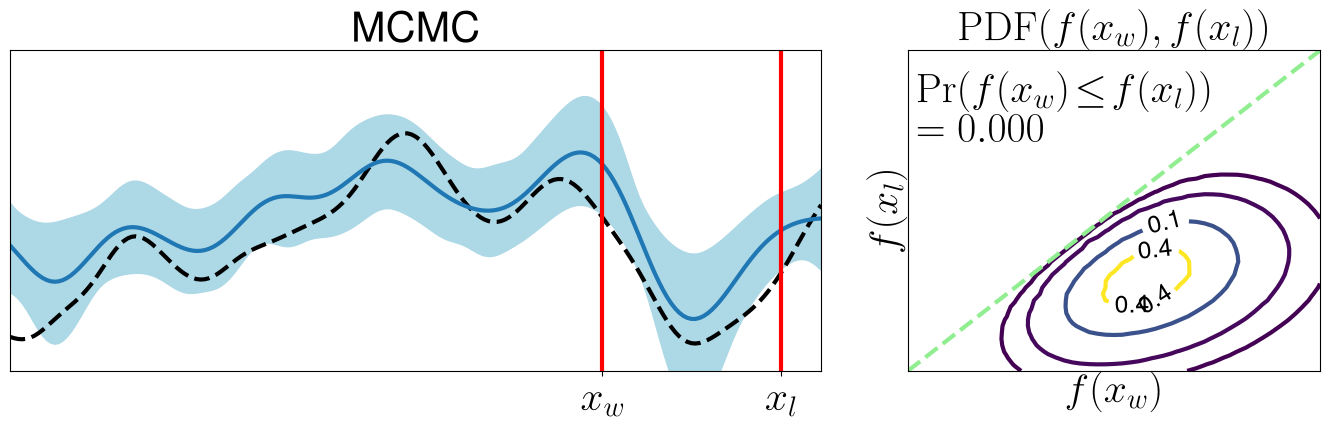

In [31]:

plt.rcParams["image.cmap"] = "viridis"
levels = [1e-3, 1e-2, 1e-1, 0.4]
y_adjst = 1.5

# Convert tensors only at the plotting boundary.
def plot_array(value):
    return value.detach().cpu().numpy()

x_plot = plot_array(X).ravel()
duel_x_plot = plot_array(X_test).ravel()
f_plot = plot_array(f_grid)


fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 14)
ax1 = plt.subplot(gs[0, :9])
ax2 = plt.subplot(gs[0, 9:])

ax1.plot(
    x_plot,
    plot_array(true_f),
    color="black",
    linestyle="dashed",
    label="black-box utility function",
)
ax1.plot(x_plot, plot_array(mean_acc), label="predictive mean")
ax1.fill_between(
    x_plot, plot_array(lower_acc), plot_array(upper_acc), color="lightblue", label=r"95 \% credible interval"
)

for duel_x in duel_x_plot:
    ax1.vlines(duel_x, -3, 3.5, linestyle="solid", color="red")
ax1.set_xticks(duel_x_plot)
ax1.set_xticklabels([r"$x_w$", r"$x_l$"])
ax1.set_yticks([])
ax1.set_xlim(0, 1)
ax1.set_ylim(-3.0, 3.5)
# ax1.legend(loc="upper left", ncol=3, bbox_to_anchor=(0, 1.27))
ax1.set_title("MCMC")
# ax1.legend(loc="upper left")

heatmap_exact = ax2.contour(
    plot_array(F1),
    plot_array(F2),
    plot_array(exact_sun_posterior_pdf_grid),
    levels=levels,
)

fmt = {}
for l in levels:
    fmt[l] = str(l)
manual_location = [(1.0, -1), (1.1, -0.5), (1.3, -0.1), (1.4, 0.5)]
ax2.clabel(heatmap_exact, fontsize=18, colors="black", fmt=fmt, manual=manual_location)

ax2.plot(
    f_plot,
    f_plot,
    linestyle="dashed",
    color="lightgreen",
    label=r"$f(x_w) \! = \! f(x_l)$",
)
# ax2.legend(loc="lower right")
ax2.set_xticks([])
ax2.set_yticks([])

ax2.set_ylabel(r"$f(x_l)$")
ax2.set_xlabel(r"$f(x_w)$")
ax2.set_title(r"${\rm PDF}(f(x_w), f(x_l))$")
ax2.text(
    np.min(f_plot) + 0.1,
    np.max(f_plot) - y_adjst,
    r"$\Pr \bigl( f(x_w) \! \leq \! f(x_l) \bigr)\!$ "
    + "\n"
    + "$= {:.3f}$ ".format(float(duel_wrong_prob_gibbs)),
)


handles, labels = ax1.get_legend_handles_labels()

plt.tight_layout()
plt.savefig("./figures/preferentialGP_MCMC_acc.pdf")
plt.show()
plt.close()

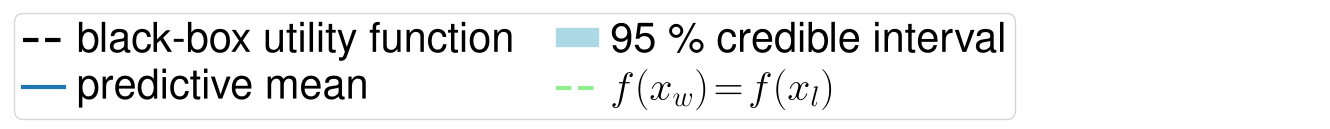

In [32]:
legend_fig = plt.figure(figsize=(14, 2))
legend_fig_ax = legend_fig.add_subplot(1, 1, 1)
legend_fig_ax.plot(
    [1], [1], color="black", linestyle="dashed", label="black-box utility function"
)
legend_fig_ax.plot([1], [1], label="predictive mean")
legend_fig_ax.fill_between(
    [1], [1], [1], color="lightblue", label=r"95 \% credible interval"
)
legend_fig_ax.plot(
    [1], [1], color="lightgreen", linestyle="dashed", label=r"$f(x_w) \! = \! f(x_l)$"
)
legend_fig_ax.axis("off")
legend_fig_ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig("./figures/preferentialGP_legend.pdf")
plt.show()
plt.close()

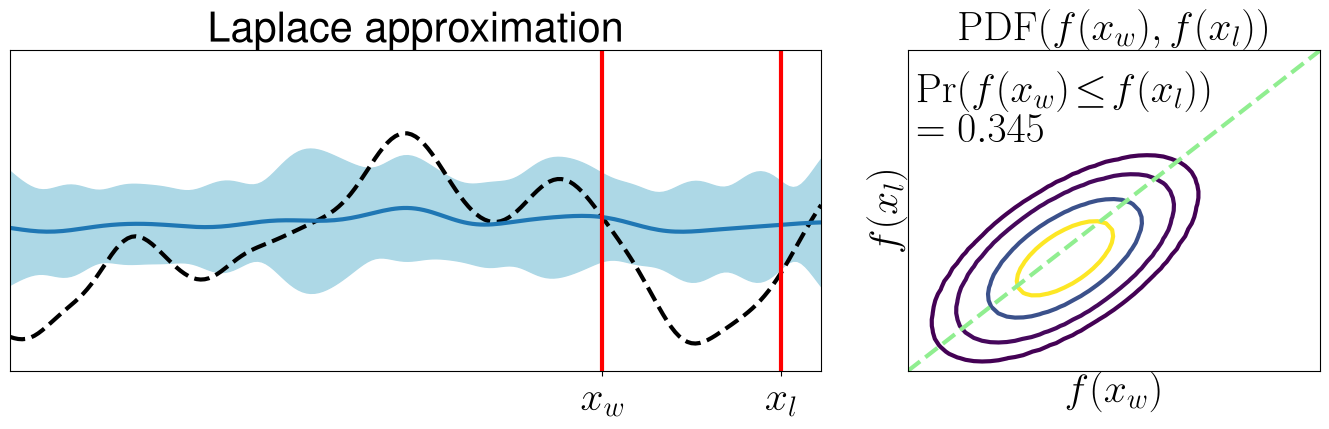

In [33]:
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 14)
ax4 = plt.subplot(gs[0, :9])
ax5 = plt.subplot(gs[0, 9:])



ax4.plot(
    x_plot,
    plot_array(true_f),
    color="black",
    linestyle="dashed",
    label="black-box utility function",
)
ax4.plot(x_plot, plot_array(mean_la), label="prediction")
ax4.fill_between(
    x_plot,
    plot_array(mean_la - 1.96 * std_la),
    plot_array(mean_la + 1.96 * std_la),
    color="lightblue",
    label="uncertainty",
)
for duel_x in duel_x_plot:
    ax4.vlines(duel_x, -3, 3.5, linestyle="solid", color="red")
ax4.set_xticks(duel_x_plot)
ax4.set_xticklabels([r"$x_w$", r"$x_l$"])
ax4.set_yticks([])
ax4.set_xlim(0, 1)
ax4.set_ylim(-3.0, 3.5)
ax4.set_title("Laplace approximation")


pdf = multivariate_normal.pdf(
    plot_array(F_eval),
    mean=plot_array(duel_mean_la_pdf).ravel(),
    cov=plot_array(duel_cov_la_pdf),
)
heatmap_exact = ax5.contour(
    plot_array(F1), plot_array(F2), pdf.reshape(F1.shape), levels=levels
)
ax5.plot(
    f_plot,
    f_plot,
    linestyle="dashed",
    color="lightgreen",
    label=r"$f(x_w) \! = \! f(x_l)$",
)
ax5.set_xticks([])
ax5.set_yticks([])

ax5.set_ylabel(r"$f(x_l)$")
ax5.set_xlabel(r"$f(x_w)$")
ax5.set_title(r"${\rm PDF}(f(x_w), f(x_l))$")
ax5.text(
    np.min(f_plot) + 0.1,
    np.max(f_plot) - y_adjst,
    r"$\Pr \bigl( f(x_w) \! \leq \! f(x_l) \bigr)\!$ "
    + "\n"
    + "$= {:.3f}$ ".format(float(duel_wrong_prob_la)),
)

plt.tight_layout()
plt.savefig("./figures/preferentialGP_LP.pdf")
plt.show()
plt.close()